# PARSeq-1


In [1]:
%pip install -q transformers albumentations editdistance pytorch-lightning lightning
import os, cv2, torch, random, editdistance, re
import numpy as np, pandas as pd
import albumentations as A
from pathlib import Path
from PIL import Image
from torchvision import transforms as T
from sklearn.model_selection import train_test_split
from transformers import get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from google.colab import drive, userdata
import kagglehub
from datetime import datetime

## ================= 1. НАСТРОЙКИ И ИНИЦИАЛИЗАЦИЯ ================

In [2]:
drive.mount('/content/drive')

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
DRIVE_DIR = Path(f"/content/drive/MyDrive/ocr_checkpoints_{timestamp}")
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = "submission_parseq.csv"
OUTPUT_CSV_FT = "submission_parseq_ft.csv"
DRIVE_OUTPUT_CSV = DRIVE_DIR / OUTPUT_CSV
DRIVE_OUTPUT_CSV_FT = DRIVE_DIR / OUTPUT_CSV_FT

# Аутентификация в Kaggle
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
os.environ['KAGGLEHUB_CACHE'] = '/content/kaggle_cache'

# Скачка датасета
dataset_path = "denccchicck/dl-lab-4-ocr-custom-dataset"
DATA_DIR = Path(kagglehub.dataset_download(dataset_path))
NESTED_DATA_DIR = DATA_DIR / 'dl-lab-4-ocr-custom-dataset-v5' # ВАЖНО! Это потерялось ранее

# Настройки обучения
BATCH_SIZE = 480
NUM_EPOCHS = 15
LR = 3e-4 # Для PARSeq лучше 3e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = os.cpu_count() or 2

# Сиды
seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.backends.cudnn.benchmark = True

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## ================= 2. ПРЕПРОЦЕССИНГ И АУГМЕНТАЦИИ =================

In [3]:
class AlphaBlending(A.ImageOnlyTransform):
    def __init__(self, alpha_range=(0.2, 0.5), always_apply=False, p=0.5):
        super().__init__(always_apply, p)
        self.alpha_range = alpha_range

    def apply(self, img, **params):
        alpha = random.uniform(*self.alpha_range)
        bg = np.full(img.shape, 240, dtype=np.uint8)
        return cv2.addWeighted(img, 1 - alpha, bg, alpha, 0)

class PadToSTRShape(A.ImageOnlyTransform):
    def __init__(self, target_h=32, target_w=128, always_apply=True, p=1.0):
        super().__init__(always_apply=always_apply, p=p)
        self.target_h = target_h
        self.target_w = target_w

    def apply(self, img, **params):
        h, w = img.shape[:2]
        new_w = int(w * (self.target_h / h))

        if new_w > self.target_w:
            return cv2.resize(img, (self.target_w, self.target_h), interpolation=cv2.INTER_CUBIC)

        img_resized = cv2.resize(img, (new_w, self.target_h), interpolation=cv2.INTER_CUBIC)
        pad_w = self.target_w - new_w
        left_pad = pad_w // 2
        right_pad = pad_w - left_pad
        return cv2.copyMakeBorder(img_resized, 0, 0, left_pad, right_pad, cv2.BORDER_CONSTANT, value=[255, 255, 255])

train_tfm = A.Compose([
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=(-0.35, -0.25), contrast_limit=0, p=1.0),
        A.RandomBrightnessContrast(brightness_limit=(0.3, 0.5), contrast_limit=0, p=1.0),
        A.RandomBrightnessContrast(brightness_limit=0, contrast_limit=(0.45, 0.55), p=1.0),
    ], p=0.6),
    A.OneOf([
        A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=1.0),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=10, p=1.0),
    ], p=0.6),
    AlphaBlending(alpha_range=(0.2, 0.5), p=0.3),
    A.MotionBlur(blur_limit=7, p=0.15),
    PadToSTRShape(always_apply=True)
])

val_tfm = A.Compose([
    PadToSTRShape(always_apply=True)
])

/tmp/ipykernel_10118/3092113388.py:13: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)


## ================= 3. ДАТАСЕТ И РАЗБИЕНИЕ =================

In [4]:
train_df = pd.read_csv(NESTED_DATA_DIR / 'train.csv')
val_df = pd.read_csv(NESTED_DATA_DIR / 'val.csv')

parseq_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(0.5, 0.5)
])

class PriceDataset(Dataset):
    def __init__(self, df, img_dir, tfms=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.tfms = tfms
        self.is_test = is_test

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = str(self.img_dir / row['Filename'])

        img = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.tfms:
            img = self.tfms(image=img)['image']

        img_pil = Image.fromarray(img)
        pixel_values = parseq_transform(img_pil)

        if self.is_test:
            return pixel_values, row['Filename']

        text = str(row['Price'])
        return pixel_values, text

train_loader = DataLoader(PriceDataset(train_df, NESTED_DATA_DIR / 'train/train', tfms=train_tfm),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)

val_loader = DataLoader(PriceDataset(val_df, NESTED_DATA_DIR / 'val/val', tfms=val_tfm),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}")

Train samples: 33500, Val samples: 15050


In [5]:
# import matplotlib.pyplot as plt
# import random
# from pathlib import Path

# def alpha_blending(image, **kwargs):
#     """Смешивание изображения с фоном"""
#     alpha = random.uniform(0.2, 0.5)
#     bg = np.full(image.shape, 240, dtype=np.uint8)
#     blended = cv2.addWeighted(image, 1 - alpha, bg, alpha, 0)
#     return blended

# def test_standalone_augs(image_path):
#     img = cv2.imdecode(np.fromfile(str(image_path), dtype=np.uint8), cv2.IMREAD_COLOR)
#     if img is None:
#         print("Image not found!")
#         return
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#     h, w = img.shape[:2]
#     crop_h = int(h * 0.1)
#     crop_w = int(w * 0.1)

#     test_transforms = [
#         ("Original", None),
#         ("Random Crop (10%)", A.Crop(x_min=crop_w, y_min=crop_h, x_max=w - crop_w, y_max=h - crop_h, p=1.0)),
#         ("Motion Blur", A.MotionBlur(blur_limit=12, p=1.0)),
#         ("Alpha Blending (0.2-0.5)", A.Lambda(image=alpha_blending, p=1.0)),
#         ("Max Darken (-0.35)", A.RandomBrightnessContrast(brightness_limit=(-0.25, -0.35), contrast_limit=0, p=1.0)),
#         ("Max Brighten (+0.5)", A.RandomBrightnessContrast(brightness_limit=(0.3, 0.5), contrast_limit=0, p=1.0)),
#         ("Hard Contrast", A.RandomBrightnessContrast(brightness_limit=0, contrast_limit=(0.5, 0.5), p=1.0)),
#         ("RGBShift", A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=1.0)),
#         ("HueShift (+10)", A.HueSaturationValue(hue_shift_limit=(10, 10), sat_shift_limit=0, val_shift_limit=0, p=1.0)),
#     ]

#     n = len(test_transforms)
#     cols = 3
#     rows = (n + cols - 1) // cols

#     plt.figure(figsize=(20, 5 * rows))
#     for i, (name, aug) in enumerate(test_transforms):
#         plt.subplot(rows, cols, i + 1)
#         if aug:
#             augmented = aug(image=img.copy())['image']
#             plt.imshow(augmented)
#         else:
#             plt.imshow(img)
#         plt.title(name)
#         plt.axis('off')
#     plt.tight_layout()
#     plt.show()

# random_idx = random.randint(0, len(train_df) - 1)
# sample_img_path = NESTED_DATA_DIR / 'train/train' / train_df.iloc[random_idx]['Filename']
# test_standalone_augs(sample_img_path)

## ================= 4. МОДЕЛЬ =================

In [6]:
model = torch.hub.load('baudm/parseq', 'parseq', pretrained=True).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(len(train_loader)*0.1), num_training_steps=len(train_loader)*NUM_EPOCHS
)
scaler = torch.amp.GradScaler('cuda')

Using cache found in /root/.cache/torch/hub/baudm_parseq_main
/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


## ================= 5. ОБУЧЕНИЕ =================

In [7]:
best_cer = float('inf')

for ep in range(1, NUM_EPOCHS + 1):
    model.train()
    tr_loss = 0

    pbar = tqdm(train_loader, desc=f"Ep {ep}/{NUM_EPOCHS} Train", leave=False)
    for px, lbl in pbar:
        px = px.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            loss = model.training_step((px, list(lbl)), batch_idx=0)
            tr_loss += loss.item()

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

    # --- Валидация ---
    model.eval()
    val_loss_mock, total_chars, total_errors, exact_matches, wrong_count = 0, 0, 0, 0, 0

    with torch.no_grad():
        for px, lbl in tqdm(val_loader, desc="Val", leave=False):
            px = px.to(DEVICE, non_blocking=True)
            truths = list(lbl)

            with torch.amp.autocast('cuda'):
                logits = model(px)
                pred_probs = logits.softmax(-1)
                preds, _ = model.tokenizer.decode(pred_probs)

            for p, t in zip(preds, truths):
                p = re.sub(r'\D', '', p)
                t = t.strip()
                if p == t: exact_matches += 1
                else: wrong_count += 1
                total_errors += editdistance.eval(p, t)
                total_chars += max(len(t), 1)

    cer = total_errors / total_chars
    acc = exact_matches / len(val_df)

    print(f"Ep {ep} | TrLoss: {tr_loss/len(train_loader):.4f} | CER: {cer:.4f} | Wrong: {wrong_count} | Exact: {acc:.4f}")

    if cer < best_cer:
        best_cer = cer
        torch.save(model.state_dict(), DRIVE_DIR / "best_parseq.pth")
        print(f"- Лучшая модель (CER: {cer:.4f}) сохранена на Drive")

Ep 1/15 Train:   0%|          | 0/131 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/module.py:451: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`


Val:   0%|          | 0/59 [00:00<?, ?it/s]

Ep 1 | TrLoss: 0.1620 | CER: 0.0024 | Wrong: 90 | Exact: 0.9940
- Лучшая модель (CER: 0.0024) сохранена на Drive


Ep 2/15 Train:   0%|          | 0/131 [00:00<?, ?it/s]

...

Val:   0%|          | 0/59 [00:00<?, ?it/s]

Ep 14 | TrLoss: 0.0179 | CER: 0.0029 | Wrong: 109 | Exact: 0.9928


Ep 15/15 Train:   0%|          | 0/131 [00:00<?, ?it/s]

Val:   0%|          | 0/59 [00:00<?, ?it/s]

Ep 15 | TrLoss: 0.0168 | CER: 0.0028 | Wrong: 103 | Exact: 0.9932


## ================= 6. ИНФЕРЕНС =================

In [9]:
model.load_state_dict(torch.load(DRIVE_DIR / "best_parseq.pth"))
model.eval()
results = []

test_df = pd.read_csv(NESTED_DATA_DIR / 'sample_submission.csv')
test_loader = DataLoader(
    # ВАЖНО: здесь строго tfms=val_tfm, иначе упадет ошибка размеров батча!
    PriceDataset(test_df, NESTED_DATA_DIR / 'test/test', tfms=val_tfm, is_test=True),
    batch_size=BATCH_SIZE*2,
    shuffle=False,
    num_workers=2
)

with torch.no_grad():
    for px, fnames in tqdm(test_loader, desc="Predicting"):
        px = px.to(DEVICE)

        with torch.amp.autocast('cuda'):
            logits = model(px)
            pred_probs = logits.softmax(-1)
            preds, _ = model.tokenizer.decode(pred_probs)

        for fname, pred in zip(fnames, preds):
            clean_price = re.sub(r'\D', '', pred)
            results.append({'Filename': fname, 'Price': int(clean_price) if clean_price else 0})

final_df = pd.DataFrame(results)
# Сохраняем локально и на Drive
final_df.to_csv(OUTPUT_CSV, index=False)
final_df.to_csv(DRIVE_OUTPUT_CSV, index=False)
print(f"Сохранено: {OUTPUT_CSV} и {DRIVE_OUTPUT_CSV}")

Predicting:   0%|          | 0/8 [00:00<?, ?it/s]

Сохранено: submission_parseq.csv и /content/drive/MyDrive/ocr_checkpoints_20260429_194331/submission_parseq.csv


## ================= 7. Анализ ошибок =================

In [12]:
import shutil

MISTAKES_DIR = DRIVE_DIR / "mistake_images"
MISTAKES_DIR.mkdir(parents=True, exist_ok=True)

class ValDatasetWithFnames(Dataset):
    def __init__(self, df, img_dir, tfms=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.tfms = tfms

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = str(self.img_dir / row['Filename'])
        img = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.tfms: img = self.tfms(image=img)['image']

        img_pil = Image.fromarray(img)
        pixel_values = parseq_transform(img_pil)
        return pixel_values, str(row['Price']), row['Filename']

error_loader = DataLoader(ValDatasetWithFnames(val_df, NESTED_DATA_DIR / 'val' / 'val', tfms=val_tfm),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

error_cases = []
with torch.no_grad():
    for px, lbl, fnames in tqdm(error_loader, desc="Analyzing & Saving Errors"):
        px = px.to(DEVICE)
        truths = list(lbl)
        with torch.amp.autocast('cuda'):
            logits = model(px)
            preds, _ = model.tokenizer.decode(logits.softmax(-1))

        for p, t, fn in zip(preds, truths, fnames):
            p = re.sub(r'\D', '', p)
            t = t.strip()
            if p != t:
                error_cases.append({'Filename': fn, 'true': t, 'pred': p})
                src_path = NESTED_DATA_DIR / 'val' / 'val' / fn
                dst_path = MISTAKES_DIR / f"pred_{p}_true_{t}_{fn}"
                try: shutil.copy(str(src_path), str(dst_path))
                except Exception as e: print(f"{fn}: {e}")

error_df = pd.DataFrame(error_cases)
print(f"Найдено ошибок: {len(error_df)}")

Analyzing & Saving Errors:   0%|          | 0/59 [00:00<?, ?it/s]

Найдено ошибок: 88


## ================= 8. Дообучение на ошибках =================

In [13]:
## ================= 8. Дообучение на ошибках =================

# --- ЗАЩИТА ОТ ОШИБОК ---
if 'error_df' not in locals():
    print("❌ Ошибка: Вы не запустили Раздел 7! Переменная error_df не найдена.")
    print("Пожалуйста, запустите ячейку с Анализом ошибок (Раздел 7) перед этой ячейкой.")
elif error_df.empty:
    print("✅ Модель не сделала ни одной ошибки на валидации! Дообучение не требуется.")
    # Просто копируем результаты базовой модели, чтобы 9-й раздел не упал
    import shutil
    shutil.copy(OUTPUT_CSV, OUTPUT_CSV_FT)
    shutil.copy(DRIVE_OUTPUT_CSV, DRIVE_OUTPUT_CSV_FT)
else:
    # --- ПОДГОТОВКА ДАННЫХ ДЛЯ FINE-TUNING ---
    hard_df = error_df[['Filename', 'true']].rename(columns={'true': 'Price'})
    hard_df['Price'] = hard_df['Price'].astype(str)
    hard_df['img_folder'] = 'val/val'

    # Увеличиваем вес сложных примеров
    hard_df_expanded = pd.concat([hard_df] * 20, ignore_index=True)

    base_train_df = pd.read_csv(NESTED_DATA_DIR / 'train.csv')
    base_train_df['Price'] = base_train_df['Price'].astype(str)
    base_train_df['img_folder'] = 'train/train'

    mix_df = pd.concat([hard_df_expanded, base_train_df.sample(n=3000, random_state=42)], ignore_index=True)

    class FineTuneDataset(Dataset):
        def __init__(self, df, base_dir, tfms=None):
            self.df = df.reset_index(drop=True)
            self.base_dir = Path(base_dir)
            self.tfms = tfms

        def __len__(self): return len(self.df)

        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img_path = str(self.base_dir / row['img_folder'] / row['Filename'])
            img = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_COLOR)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if self.tfms: img = self.tfms(image=img)['image']
            img_pil = Image.fromarray(img)
            return parseq_transform(img_pil), str(row['Price'])

    fine_tune_loader = DataLoader(FineTuneDataset(mix_df, NESTED_DATA_DIR, tfms=train_tfm),
                                  batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    # --- ДООБУЧЕНИЕ PARSEQ ---
    model_ft = torch.hub.load('baudm/parseq', 'parseq', pretrained=False).to(DEVICE)
    model_ft.load_state_dict(torch.load(DRIVE_DIR / "best_parseq.pth"))

    optimizer = torch.optim.AdamW(model_ft.parameters(), lr=1e-6, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=len(fine_tune_loader)*3)
    scaler = torch.amp.GradScaler('cuda')

    model_ft.train()
    print("Starting Fine-tuning...")
    for ep in range(1, 4):
        tr_loss = 0
        pbar = tqdm(fine_tune_loader, desc=f"Fine-tune Ep {ep}")
        for px, lbl in pbar:
            px = px.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                loss = model_ft.training_step((px, list(lbl)), batch_idx=0)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            tr_loss += loss.item()
            pbar.set_postfix(loss=f"{tr_loss/len(pbar):.4f}")

    # --- ИНФЕРЕНС ---
    model_ft.eval()

    # Убеждаемся, что test_loader объявлен правильно (с val_tfm)
    test_loader = DataLoader(
        PriceDataset(pd.read_csv(NESTED_DATA_DIR / 'sample_submission.csv'), NESTED_DATA_DIR / 'test/test', tfms=val_tfm, is_test=True),
        batch_size=BATCH_SIZE*2, shuffle=False, num_workers=0
    )

    results_ft = []
    with torch.no_grad():
        for px, fnames in tqdm(test_loader, desc="Predicting (FT)"):
            px = px.to(DEVICE)
            with torch.amp.autocast('cuda'):
                preds, _ = model_ft.tokenizer.decode(model_ft(px).softmax(-1))
            for fname, pred in zip(fnames, preds):
                clean_price = re.sub(r'\D', '', pred)
                results_ft.append({'Filename': fname, 'Price': int(clean_price) if clean_price else 0})

    final_df_ft = pd.DataFrame(results_ft)
    final_df_ft.to_csv(OUTPUT_CSV_FT, index=False)
    final_df_ft.to_csv(DRIVE_OUTPUT_CSV_FT, index=False)
    print(f"Готово! Сабмишн сохранен как {OUTPUT_CSV_FT}")

Using cache found in /root/.cache/torch/hub/baudm_parseq_main


Starting Fine-tuning...


Fine-tune Ep 1:   0%|          | 0/19 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/module.py:451: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`


Fine-tune Ep 2:   0%|          | 0/19 [00:00<?, ?it/s]

Fine-tune Ep 3:   0%|          | 0/19 [00:00<?, ?it/s]

Predicting (FT):   0%|          | 0/8 [00:00<?, ?it/s]

Готово! Сабмишн сохранен как submission_parseq_ft.csv


## ================= 9. Анализ разницы предсказаний дообученной модели и исходной =================

In [14]:
df_base = pd.read_csv(OUTPUT_CSV)
df_ft = pd.read_csv(OUTPUT_CSV_FT)
df_comp = pd.merge(df_base, df_ft, on='Filename', suffixes=('_base', '_ft'))
diff_df = df_comp[df_comp['Price_base'] != df_comp['Price_ft']].copy()

DISC_DIR = DRIVE_DIR / "discrepancies"
DISC_DIR.mkdir(parents=True, exist_ok=True)
diff_df.to_csv(DRIVE_DIR / "comparison_summary.csv", index=False)

test_img_dir = NESTED_DATA_DIR / 'test' / 'test'
for _, row in diff_df.iterrows():
    src = test_img_dir / row['Filename']
    if src.exists():
        shutil.copy(str(src), str(DISC_DIR / f"base_{row['Price_base']}_ft_{row['Price_ft']}_{row['Filename']}"))

print(f"Готово! Различий: {len(diff_df)}")

Готово! Различий: 1


In [16]:
if not diff_df.empty:
    display(diff_df)
else:
    print("Различий не найдено.")

,Filename,Price_base,Price_ft
2112,74_10-B4-1D-E0-2E-CC_2026-01-22-18-03-03.jpg,110,119


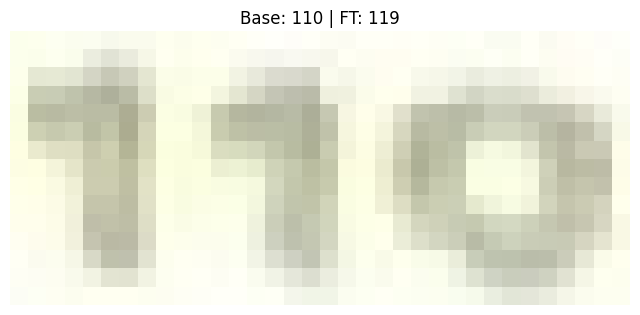

In [17]:
import matplotlib.pyplot as plt

if not diff_df.empty:
    row = diff_df.iloc[0]
    img_path = NESTED_DATA_DIR / 'test/test' / row['Filename']

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.title(f"Base: {row['Price_base']} | FT: {row['Price_ft']}")
    plt.axis('off')
    plt.show()
else:
    print("Нет различий для отображения.")

## ================= 10. ИНФЕРЕНС С ПРОДВИНУТЫМ TTA =================


In [21]:
from collections import Counter

OUTPUT_CSV_TTA = "submission_parseq_tta.csv"
DRIVE_OUTPUT_CSV_TTA = DRIVE_DIR / OUTPUT_CSV_TTA

# --- Кастомный трансформ: Контраст по перцентилям ---
class PercentileContrast(A.ImageOnlyTransform):
    def __init__(self, lower=1.0, upper=99.0, always_apply=True, p=1.0):
        super().__init__(always_apply=always_apply, p=p)
        self.lower = lower
        self.upper = upper

    def apply(self, img, **params):
        # Вычисляем перцентили
        p_low, p_high = np.percentile(img, (self.lower, self.upper))
        # Растягиваем контраст, игнорируя выбросы (блики/черные точки)
        if p_high > p_low: # Защита от монотонных картинок
            img_stretched = np.clip((img - p_low) / (p_high - p_low) * 255.0, 0, 255)
            return img_stretched.astype(np.uint8)
        return img

# --- Сборка 7 вариантов TTA ---
# Индекс 0 — оригинал. При ничьей в голосовании побеждает он.
tta_transforms = [
    # 0. Оригинал (база)
    A.Compose([PadToSTRShape(always_apply=True)]),

    # 1. Локальный контраст (спасает от теней на половине ценника)
    A.Compose([A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0), PadToSTRShape(always_apply=True)]),

    # 2. Глобальный контраст (спасает выцветшие/тусклые ценники)
    A.Compose([PercentileContrast(lower=15.0, upper=85.0, p=1.0), PadToSTRShape(always_apply=True)]),

    # 3. Резкость (повышает четкость краев символов)
    A.Compose([A.Sharpen(alpha=(0.3, 0.5), lightness=(0.5, 1.0), p=1.0), PadToSTRShape(always_apply=True)]),

    # 4. Обесцвечивание (убирает хроматический шум)
    A.Compose([A.ToGray(p=1.0), PadToSTRShape(always_apply=True)]),

    # 5. Легкий поворот вправо (спасает криво сфотканные)
    A.Compose([A.Rotate(limit=(3, 3), border_mode=cv2.BORDER_CONSTANT, value=[255, 255, 255], p=1.0), PadToSTRShape(always_apply=True)]),

    # 6. Легкий поворот влево
    A.Compose([A.Rotate(limit=(-3, -3), border_mode=cv2.BORDER_CONSTANT, value=[255, 255, 255], p=1.0), PadToSTRShape(always_apply=True)])
]

class TTADataset(Dataset):
    def __init__(self, df, img_dir):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = str(self.img_dir / row['Filename'])
        img = cv2.imdecode(np.fromfile(img_path, dtype=np.uint8), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        tta_pixels = []
        for tfm in tta_transforms:
            aug_img = tfm(image=img)['image']
            tta_pixels.append(parseq_transform(Image.fromarray(aug_img)))

        # Возвращаем стопку из 7 тензоров
        return torch.stack(tta_pixels), row['Filename']

# Используем модель (можете заменить на model_ft, если дообучение было)
model_tta = torch.hub.load('baudm/parseq', 'parseq', pretrained=False).to(DEVICE)
model_tta.load_state_dict(torch.load(DRIVE_DIR / "best_parseq.pth"))
model_tta.eval()

test_df = pd.read_csv(NESTED_DATA_DIR / 'sample_submission.csv')

# Уменьшаем батч, так как 1 картинка = 7 тензоров
tta_loader = DataLoader(
    TTADataset(test_df, NESTED_DATA_DIR / 'test' / 'test'),
    batch_size=max(1, BATCH_SIZE // 3),
    shuffle=False,
    num_workers=0
)

results_tta = []

with torch.no_grad():
    for px, fnames in tqdm(tta_loader, desc="Predicting with Advanced TTA"):
        B, N_TTA, C, H, W = px.shape
        px_flat = px.view(B * N_TTA, C, H, W).to(DEVICE)

        with torch.amp.autocast('cuda'):
            logits = model_tta(px_flat)
            pred_probs = logits.softmax(-1)
            preds_flat, _ = model_tta.tokenizer.decode(pred_probs)

        for i in range(B):
            # Достаем 7 предсказаний для текущей картинки
            img_preds = preds_flat[i * N_TTA : (i + 1) * N_TTA]

            # Чистим предсказания от не-цифр
            clean_preds = [re.sub(r'\D', '', p) for p in img_preds]
            clean_preds = [p if p else "0" for p in clean_preds]

            # ГОЛОСОВАНИЕ
            # Если мнения разделятся (например, 3 против 3), победит тот вариант,
            # который встретился в списке первым. Так как TTA_0 — это оригинал,
            # он имеет приоритет в спорных ситуациях.
            vote_counts = Counter(clean_preds)
            best_pred = vote_counts.most_common(1)[0][0]

            results_tta.append({'Filename': fnames[i], 'Price': int(best_pred)})

final_df_tta = pd.DataFrame(results_tta)
final_df_tta.to_csv(OUTPUT_CSV_TTA, index=False)
final_df_tta.to_csv(DRIVE_OUTPUT_CSV_TTA, index=False)

print(f"Готово! Сабмишн с продвинутым TTA (7 вариантов) сохранен: {OUTPUT_CSV_TTA}")

/tmp/ipykernel_10118/3092113388.py:13: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)
/tmp/ipykernel_10118/2174530057.py:9: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)
/tmp/ipykernel_10118/2174530057.py:41: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Compose([A.Rotate(limit=(3, 3), border_mode=cv2.BORDER_CONSTANT, value=[255, 255, 255], p=1.0), PadToSTRShape(always_apply=True)]),
/tmp/ipykernel_10118/2174530057.py:44: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Compose([A.Rotate(limit=(-3, -3), border_mode=cv2.BORDER_CONSTANT, value=[255, 255, 255], p=1.0), PadToSTRShape(always_apply=True)])
Using cache found in /root/.cache/torch/hub/baudm_parseq_main


Predicting with Advanced TTA:   0%|          | 0/45 [00:00<?, ?it/s]

Готово! Сабмишн с продвинутым TTA (7 вариантов) сохранен: submission_parseq_tta.csv


Количество различий после TTA: 9


,Filename,Price_ft,Price_tta
202,0_D0-CF-13-3A-25-7C_16_2025-11-15-17-02-15.jpg,961,96
569,35_D0-CF-13-22-08-78_2026-01-22-21-57-47.jpg,263,203
958,12_D0-CF-13-19-05-F0_2026-01-22-17-56-32.jpg,799,700
1745,16_D0-CF-13-24-C4-74_2026-01-22-18-01-42.jpg,322,32
1804,47_D0-CF-13-21-6A-4C_2026-01-22-14-00-59.jpg,269,369
1956,0_10-B4-1D-C7-FD-90_8_2025-11-11-19-59-34.jpg,842,84
2112,74_10-B4-1D-E0-2E-CC_2026-01-22-18-03-03.jpg,119,110
2723,19_D0-CF-13-23-75-30_2026-01-22-17-57-47.jpg,222,227
2999,0_10-B4-1D-E0-34-84_25_2025-11-17-19-57-03.jpg,169,69


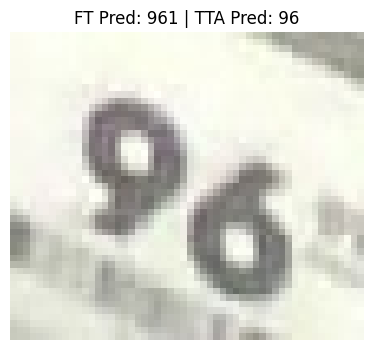

In [23]:
import pandas as pd
import re
import cv2
import matplotlib.pyplot as plt

# Сравниваем TTA с Fine-tuned (предыдущим)
df_ft = pd.read_csv('submission_parseq_ft.csv')
df_tta = pd.read_csv('submission_parseq_tta.csv')

df_comp_tta = pd.merge(df_ft, df_tta, on='Filename', suffixes=('_ft', '_tta'))
diff_tta = df_comp_tta[df_comp_tta['Price_ft'] != df_comp_tta['Price_tta']].copy()

print(f"Количество различий после TTA: {len(diff_tta)}")

if not diff_tta.empty:
    display(diff_tta)

    # Визуализируем первое различие
    row = diff_tta.iloc[0]
    img_path = NESTED_DATA_DIR / 'test/test' / row['Filename']
    img = cv2.imdecode(np.fromfile(str(img_path), dtype=np.uint8), cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.title(f"FT Pred: {row['Price_ft']} | TTA Pred: {row['Price_tta']}")
    plt.axis('off')
    plt.show()
else:
    print("TTA не изменил ни одного предсказания относительно FT-модели.")

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d0f885d5620>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1671, in _shutdown_workers
  File "/usr/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._selector.poll(timeout)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Keyboar

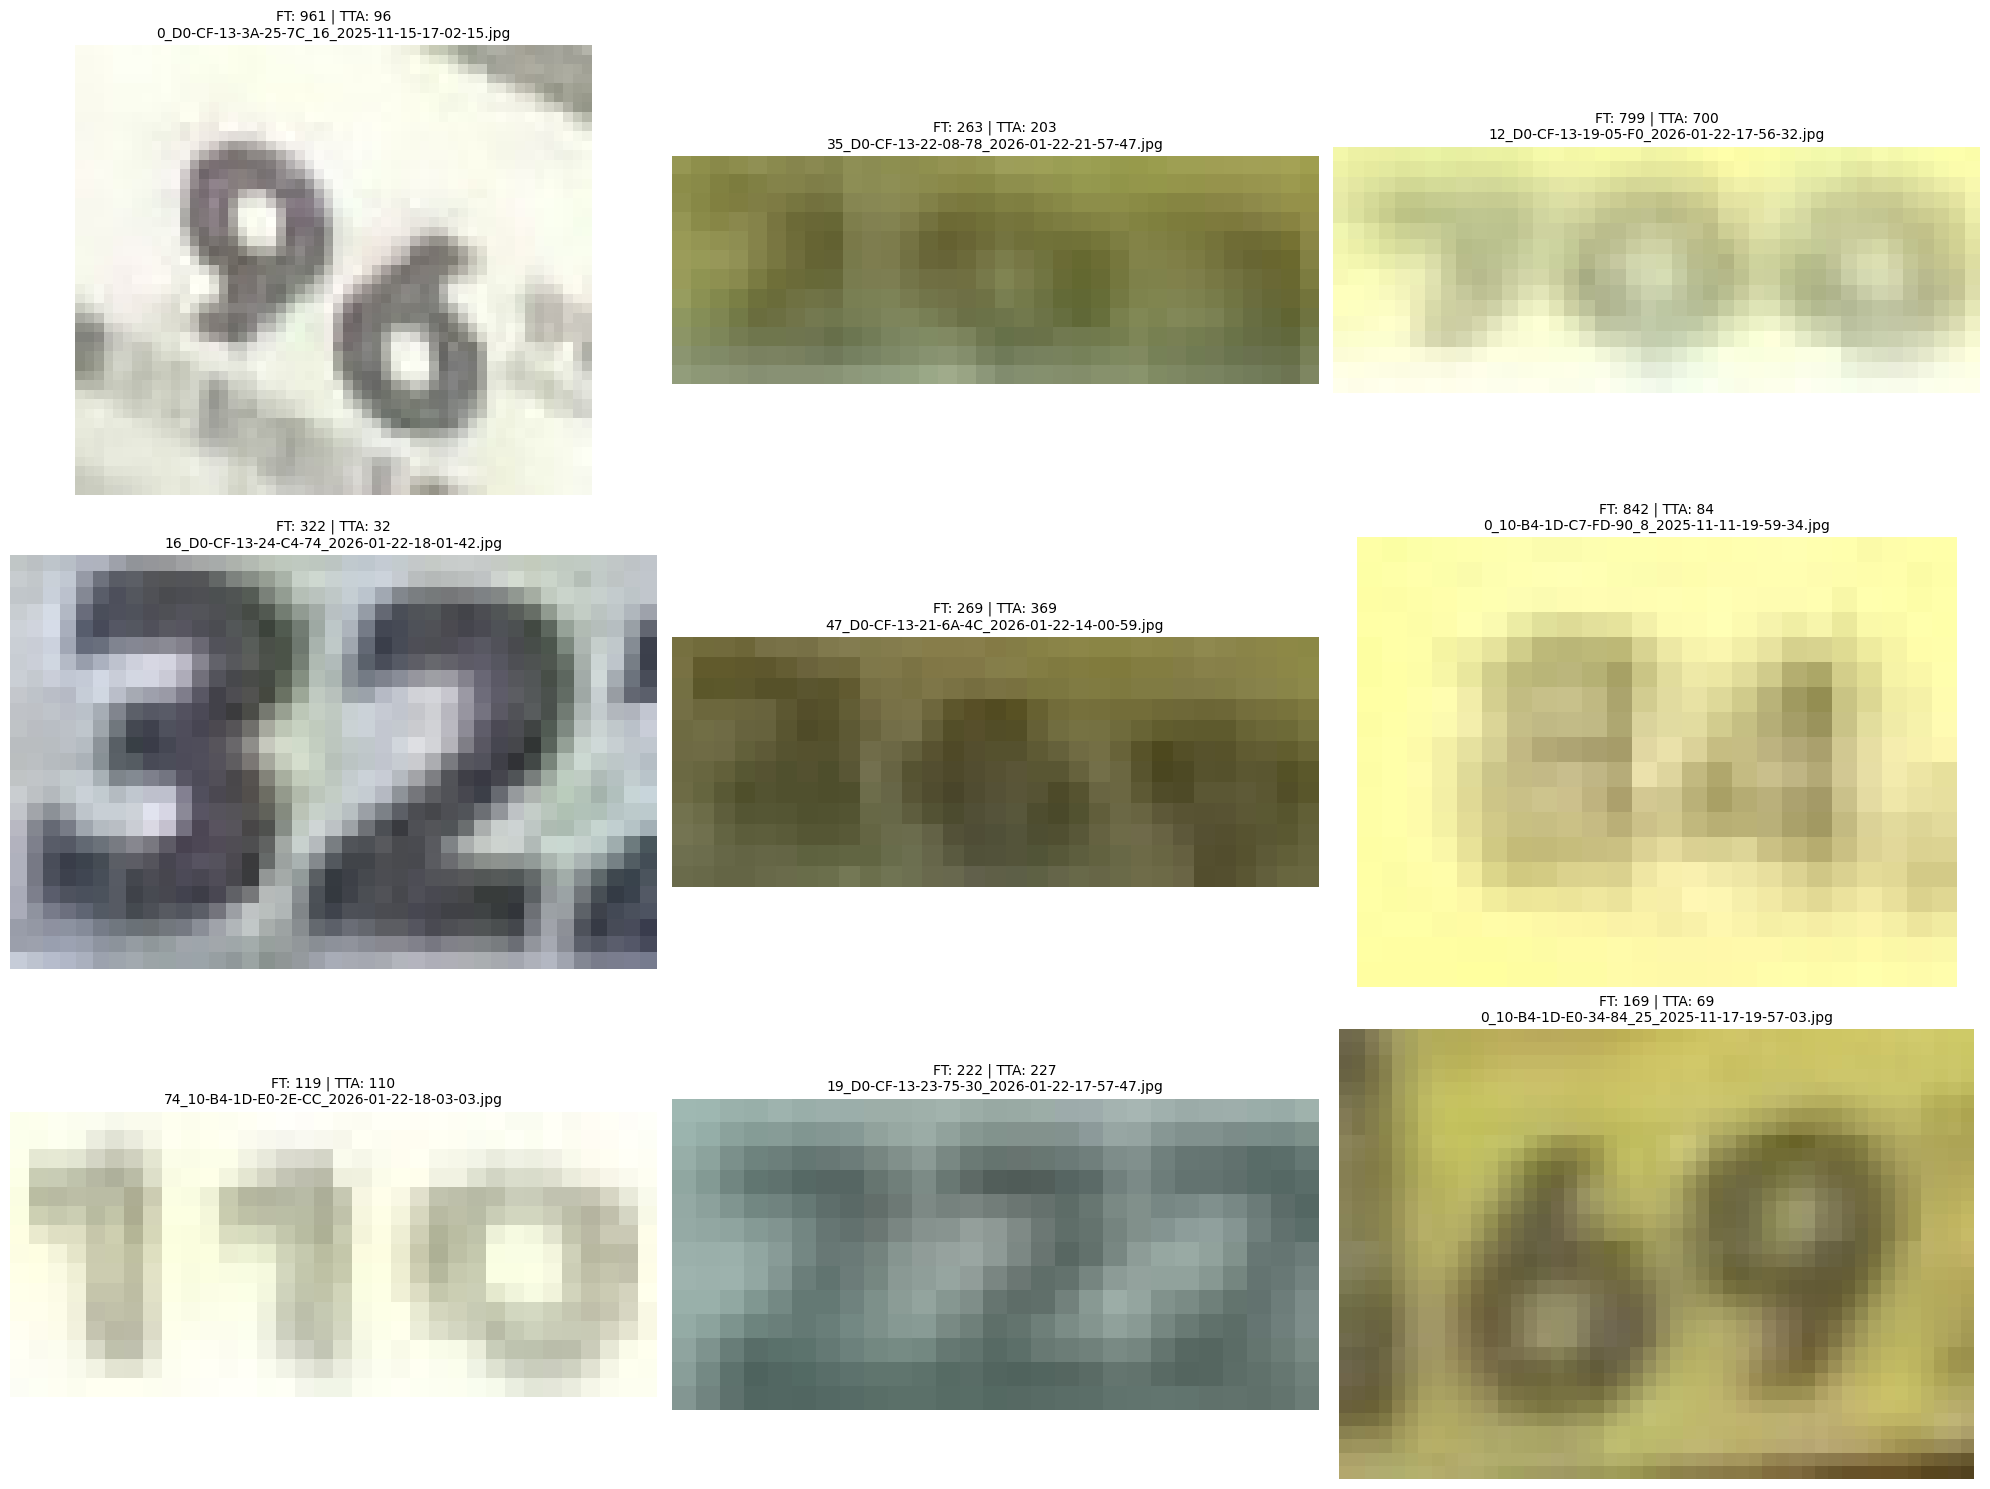

Все изображения (9 шт.) сохранены в: /content/drive/MyDrive/ocr_checkpoints_20260429_194331/tta_discrepancies


In [20]:
import shutil

# Папка для сохранения на Диске
TTA_DISC_DIR = DRIVE_DIR / "tta_discrepancies"
TTA_DISC_DIR.mkdir(parents=True, exist_ok=True)

if not diff_tta.empty:
    n = len(diff_tta)
    cols = 3
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(20, 5 * rows))

    for i, (_, row) in enumerate(diff_tta.iterrows()):
        img_path = NESTED_DATA_DIR / 'test/test' / row['Filename']
        img = cv2.imdecode(np.fromfile(str(img_path), dtype=np.uint8), cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Визуализация
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(f"FT: {row['Price_ft']} | TTA: {row['Price_tta']}\n{row['Filename']}", fontsize=10)
        plt.axis('off')

        # Сохранение на Диск
        dst_path = TTA_DISC_DIR / f"ft_{row['Price_ft']}_tta_{row['Price_tta']}_{row['Filename']}"
        shutil.copy(str(img_path), str(dst_path))

    plt.tight_layout()
    plt.show()
    print(f"Все изображения ({n} шт.) сохранены в: {TTA_DISC_DIR}")
else:
    print("Различий для вывода нет.")